# Round I Data Analysis

# Cell 1 — Imports & data loading

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Assumes you've cloned Isaac's prosperity3bt fork
DATA_DIR = Path("../../imc-prosperity-3-backtester/prosperity3bt/resources/round1")

# Load prices (semicolon-delimited)
prices = pd.concat([
    pd.read_csv(DATA_DIR / f"prices_round_1_day_{d}.csv", sep=";")
    for d in [-2, -1, 0]
], ignore_index=True)

# Load trades
trades = pd.concat([
    pd.read_csv(DATA_DIR / f"trades_round_1_day_{d}.csv", sep=";")
    for d in [-2, -1, 0]
], ignore_index=True)

osmium = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()
pepper = prices[prices["product"] == "INTARIAN_PEPPER_ROOT"].copy()

osmium = osmium[osmium["bid_price_1"].notna() & osmium["ask_price_1"].notna()].copy()
pepper = pepper[pepper["bid_price_1"].notna() & pepper["ask_price_1"].notna()].copy()

# Global tick index for multi-day plots
for df in [osmium, pepper]:
    df["tick"] = range(len(df))

print(f"Osmium: {len(osmium)} rows, Pepper: {len(pepper)} rows")
print(f"Trades: {len(trades)} rows")

Osmium: 27644 rows, Pepper: 27688 rows
Trades: 2276 rows


# Cell 2 — Mid price overview



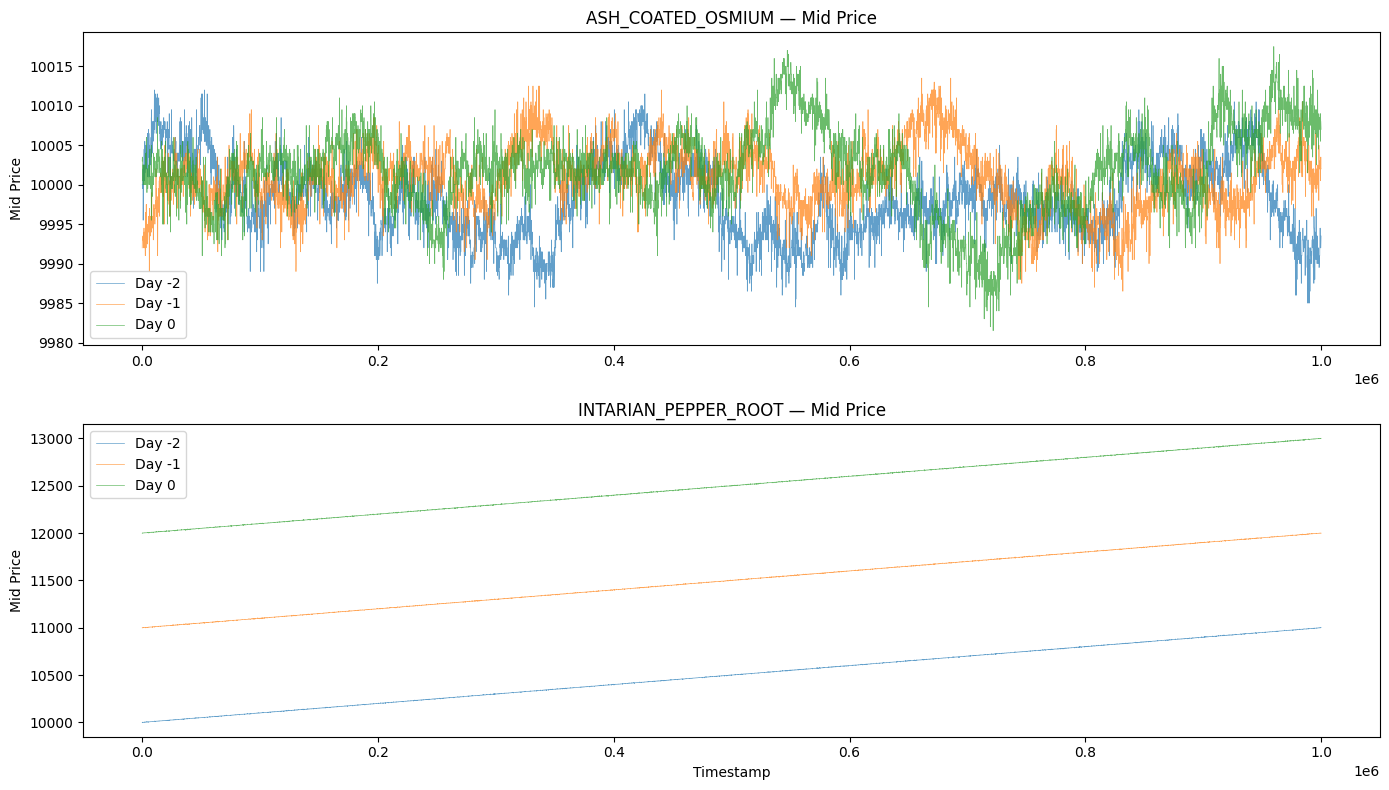

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, df, name in [(axes[0], osmium, "ASH_COATED_OSMIUM"),
                      (axes[1], pepper, "INTARIAN_PEPPER_ROOT")]:
    for day, grp in df.groupby("day"):
        ax.plot(grp["timestamp"], grp["mid_price"], label=f"Day {day}", alpha=0.7, linewidth=0.5)
    ax.set_title(f"{name} — Mid Price")
    ax.set_ylabel("Mid Price")
    ax.legend()

axes[1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

# Cell 3 — Spread distribution



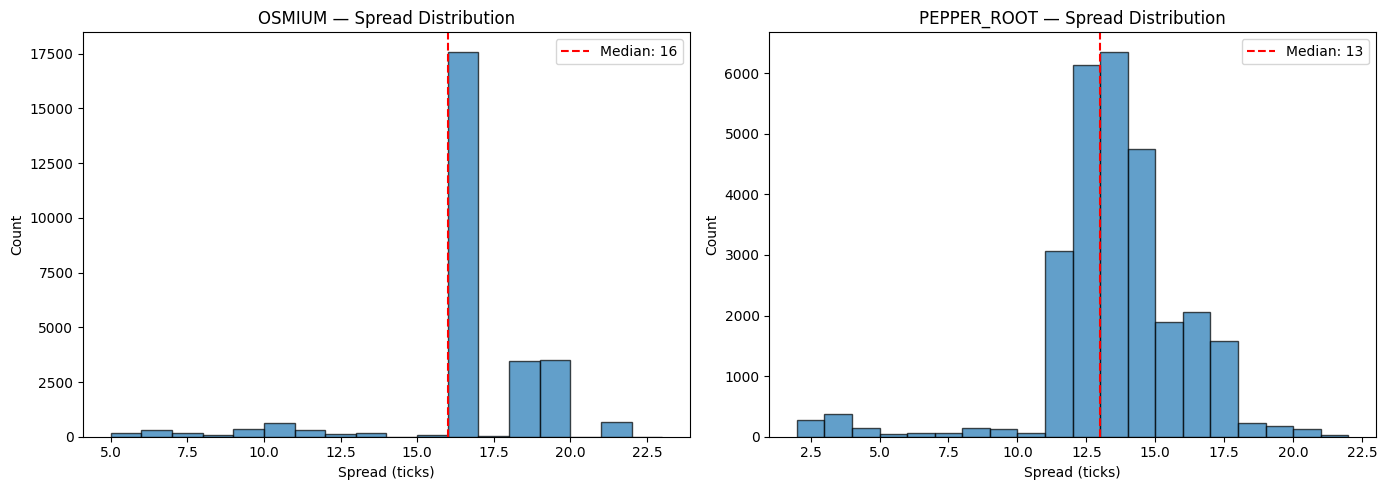

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], osmium, "OSMIUM"), (axes[1], pepper, "PEPPER_ROOT")]:
    spread = df["ask_price_1"] - df["bid_price_1"]
    spread = spread.dropna()
    ax.hist(spread, bins=range(int(spread.min()), int(spread.max()) + 2), edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} — Spread Distribution")
    ax.set_xlabel("Spread (ticks)")
    ax.set_ylabel("Count")
    ax.axvline(spread.median(), color="red", linestyle="--", label=f"Median: {spread.median():.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

# Cell 4 — Returns & autocorrelation

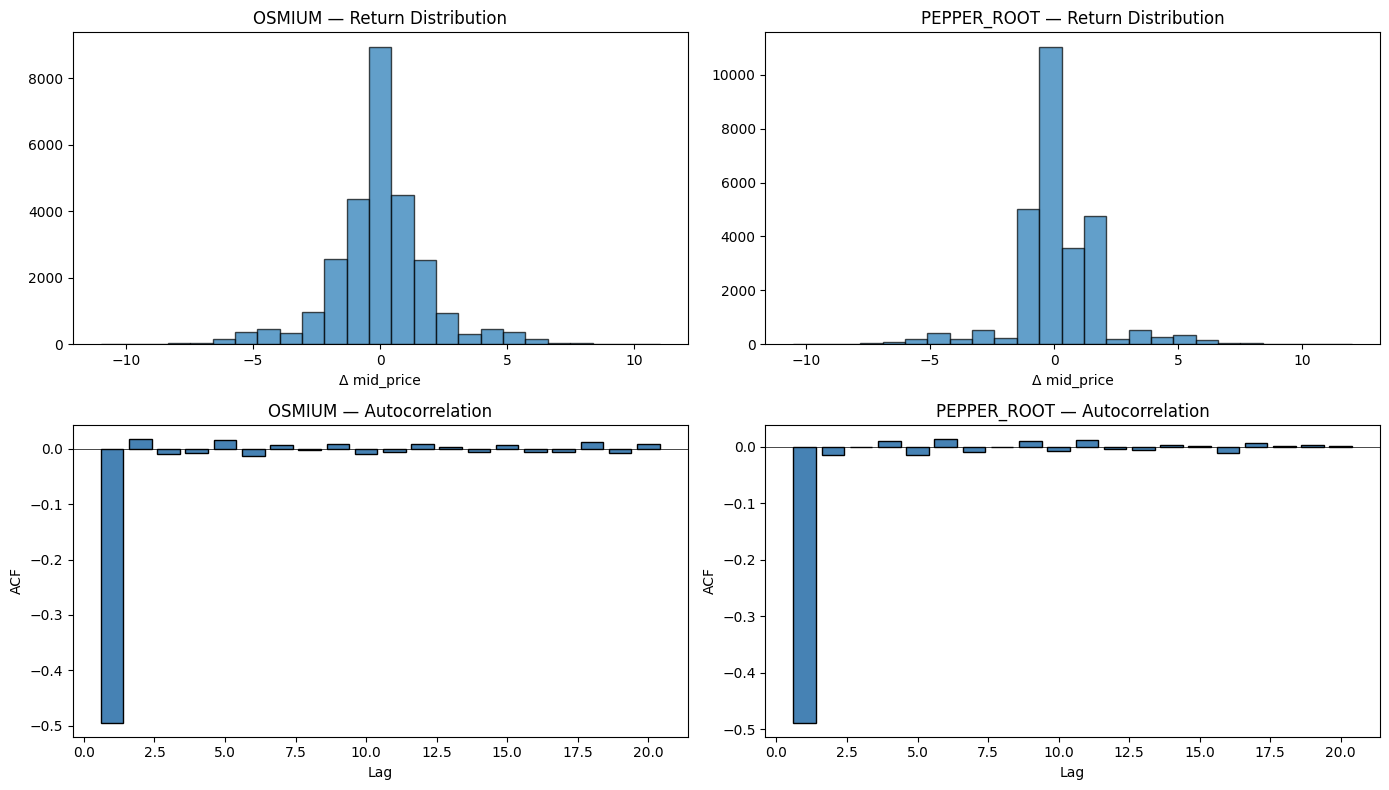

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, (df, name) in enumerate([(osmium, "OSMIUM"), (pepper, "PEPPER_ROOT")]):
    returns = df.groupby("day")["mid_price"].diff().dropna()

    # Return distribution
    axes[0, col].hist(returns, bins=25, edgecolor="black", alpha=0.7)
    axes[0, col].set_title(f"{name} — Return Distribution")
    axes[0, col].set_xlabel("Δ mid_price")

    # Autocorrelation
    acf = [returns.autocorr(lag=k) for k in range(1, 21)]
    axes[1, col].bar(range(1, 21), acf, color="steelblue", edgecolor="black")
    axes[1, col].axhline(0, color="black", linewidth=0.5)
    axes[1, col].set_title(f"{name} — Autocorrelation")
    axes[1, col].set_xlabel("Lag")
    axes[1, col].set_ylabel("ACF")

plt.tight_layout()
plt.show()

# Cell 5 — OSMIUM deep dive: mean reversion

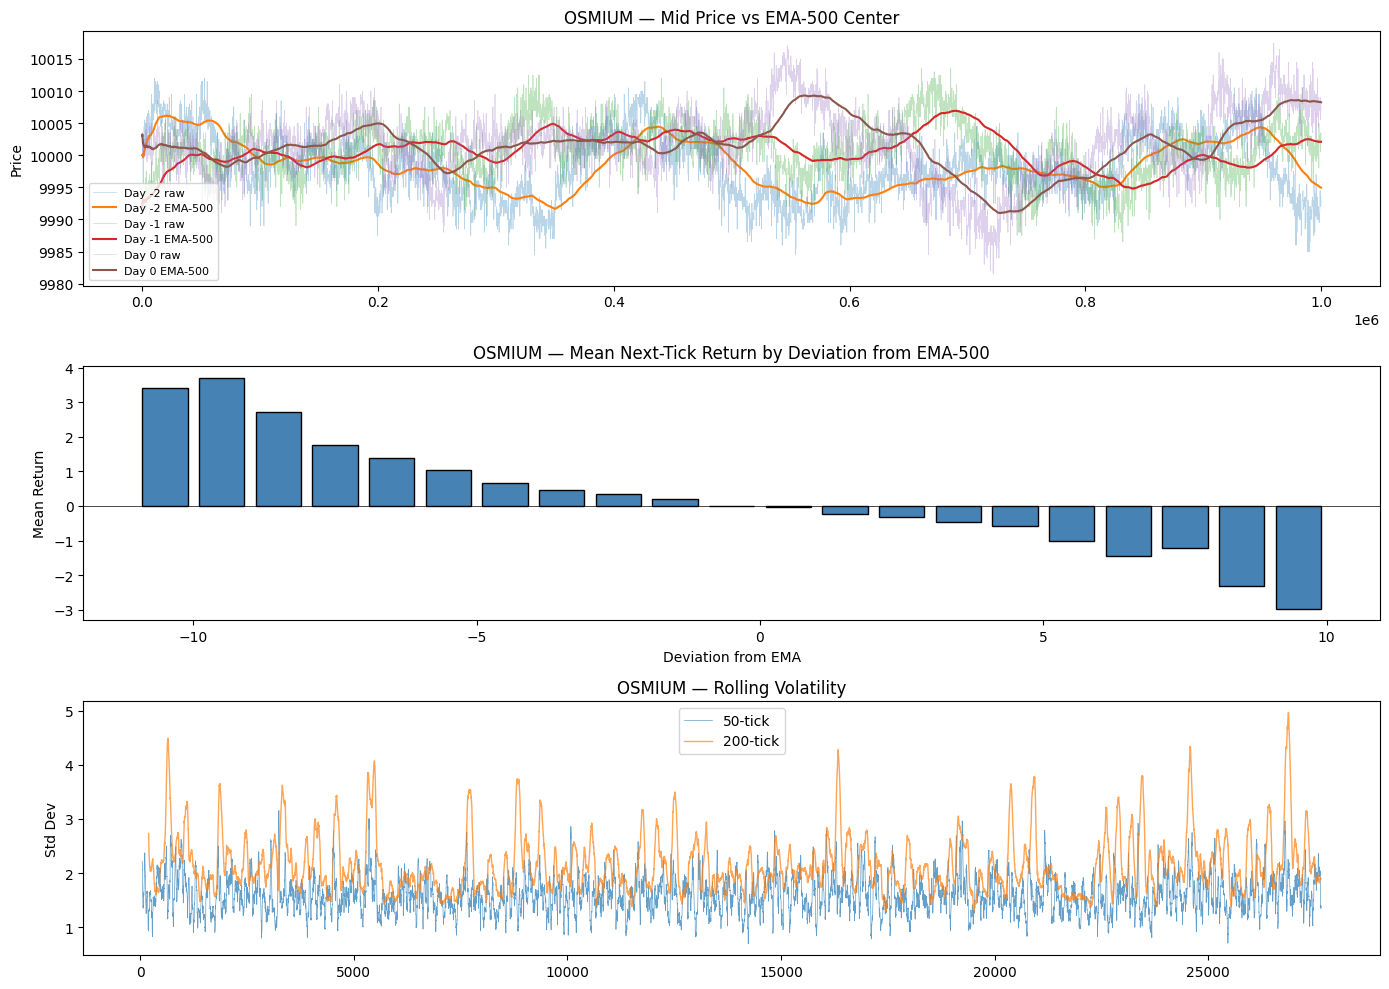

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# EMA center vs raw mid
for day, grp in osmium.groupby("day"):
    mid = grp["mid_price"].values
    # 500-tick EMA
    ema = pd.Series(mid).ewm(span=500).mean().values
    t = grp["timestamp"].values

    axes[0].plot(t, mid, alpha=0.3, linewidth=0.5, label=f"Day {day} raw")
    axes[0].plot(t, ema, linewidth=1.5, label=f"Day {day} EMA-500")

axes[0].set_title("OSMIUM — Mid Price vs EMA-500 Center")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

# Deviation from EMA → next-tick return
mid_all = osmium["mid_price"].values
ema_all = pd.Series(mid_all).ewm(span=500).mean().values
deviation = mid_all - ema_all
next_return = np.diff(mid_all)

dev = deviation[:-1]  # align with next_return
bins = np.linspace(-15, 15, 31)
bin_idx = np.digitize(dev, bins)

mean_ret = []
bin_centers = []
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 20:
        mean_ret.append(next_return[mask].mean())
        bin_centers.append((bins[i-1] + bins[i]) / 2)

axes[1].bar(bin_centers, mean_ret, width=0.8, color="steelblue", edgecolor="black")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("OSMIUM — Mean Next-Tick Return by Deviation from EMA-500")
axes[1].set_xlabel("Deviation from EMA")
axes[1].set_ylabel("Mean Return")

# Rolling volatility
roll_50 = pd.Series(mid_all).rolling(50).std()
roll_200 = pd.Series(mid_all).rolling(200).std()
axes[2].plot(roll_50.values, label="50-tick", alpha=0.7, linewidth=0.5)
axes[2].plot(roll_200.values, label="200-tick", alpha=0.7, linewidth=1)
axes[2].set_title("OSMIUM — Rolling Volatility")
axes[2].legend()
axes[2].set_ylabel("Std Dev")

plt.tight_layout()
plt.show()

# Cell 6 — PEPPER_ROOT deep dive: drift

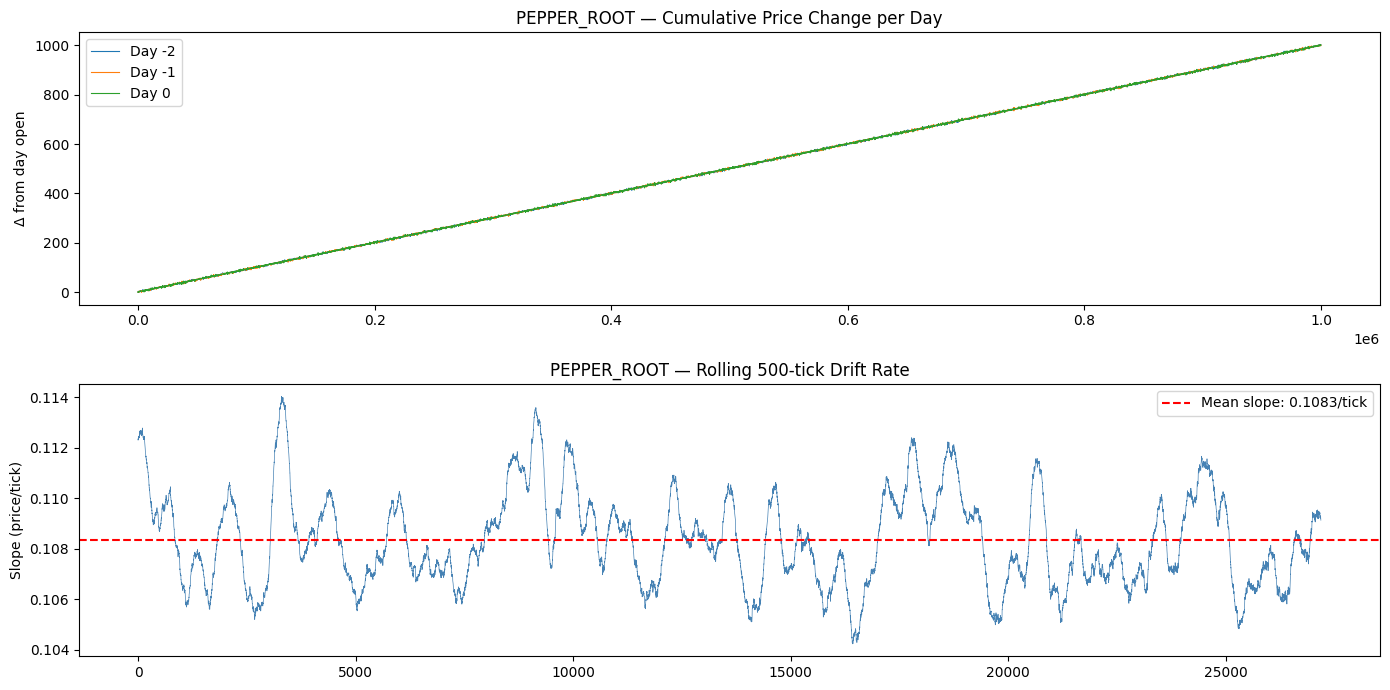

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Cumulative drift per day
for day, grp in pepper.groupby("day"):
    mid = grp["mid_price"].values
    cum_return = mid - mid[0]
    axes[0].plot(grp["timestamp"].values, cum_return, label=f"Day {day}", linewidth=0.8)

axes[0].set_title("PEPPER_ROOT — Cumulative Price Change per Day")
axes[0].set_ylabel("Δ from day open")
axes[0].legend()

# Drift rate (rolling 500-tick slope)
mid_all = pepper["mid_price"].values
slopes = []
window = 500
for i in range(window, len(mid_all)):
    x = np.arange(window)
    y = mid_all[i-window:i]
    slope = np.polyfit(x, y, 1)[0]
    slopes.append(slope)

axes[1].plot(slopes, linewidth=0.5, color="steelblue")
axes[1].axhline(np.mean(slopes), color="red", linestyle="--", label=f"Mean slope: {np.mean(slopes):.4f}/tick")
axes[1].set_title("PEPPER_ROOT — Rolling 500-tick Drift Rate")
axes[1].set_ylabel("Slope (price/tick)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cell 7 — Trade activity



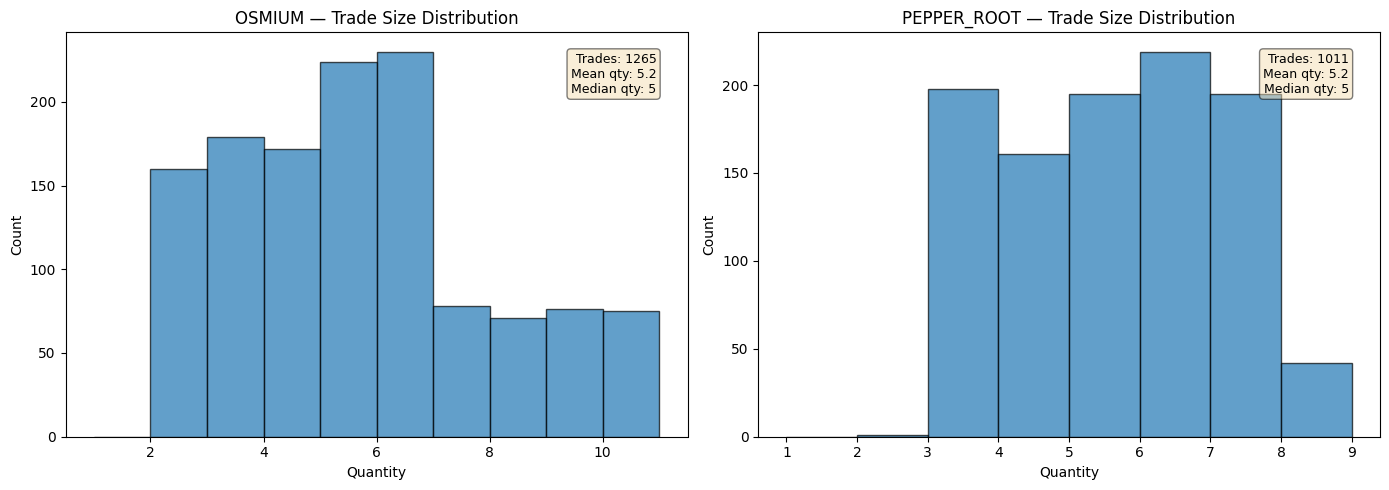

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, symbol, name in [(axes[0], "ASH_COATED_OSMIUM", "OSMIUM"),
                          (axes[1], "INTARIAN_PEPPER_ROOT", "PEPPER_ROOT")]:
    t = trades[trades["symbol"] == symbol]
    ax.hist(t["quantity"], bins=range(1, int(t["quantity"].max()) + 2),
            edgecolor="black", alpha=0.7)
    ax.set_title(f"{name} — Trade Size Distribution")
    ax.set_xlabel("Quantity")
    ax.set_ylabel("Count")

    stats = f"Trades: {len(t)}\nMean qty: {t['quantity'].mean():.1f}\nMedian qty: {t['quantity'].median():.0f}"
    ax.text(0.95, 0.95, stats, transform=ax.transAxes, va="top", ha="right",
            fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

# Cell 8 — Summary stats table

In [26]:
summary = []
for name, df in [("OSMIUM", osmium), ("PEPPER_ROOT", pepper)]:
    mid = df["mid_price"].dropna()
    spread = (df["ask_price_1"] - df["bid_price_1"]).dropna()
    ret = mid.diff().dropna()
    summary.append({
        "Product": name,
        "Mid Mean": f"{mid.mean():.2f}",
        "Mid Std": f"{mid.std():.2f}",
        "Mid Range": f"{mid.max() - mid.min():.0f}",
        "Spread Median": f"{spread.median():.0f}",
        "Drift/tick": f"{ret.mean():.4f}",
        "ACF(1)": f"{ret.autocorr(lag=1):.3f}",
        "Ticks": len(mid),
    })

pd.DataFrame(summary)

,Product,Mid Mean,Mid Std,Mid Range,Spread Median,Drift/tick,ACF(1),Ticks
0,OSMIUM,10000.21,4.86,36,16,0.0003,-0.494,27644
1,PEPPER_ROOT,11502.32,866.15,3002,13,0.1084,-0.488,27688


# Scanning for insiders

In [27]:
# Scan for informed trader patterns in market trades
# In P3, "Olivia" bought exactly 15 lots at daily lows, sold 15 at daily highs

# Check if buyer/seller fields are populated
print("Unique buyers:", trades["buyer"].unique()[:20])
print("Unique sellers:", trades["seller"].unique()[:20])
print()

# Check for fixed-quantity patterns (Olivia always traded exactly 15)
print("Quantity distribution:")
print(trades["quantity"].value_counts().head(10))

Unique buyers: [nan]
Unique sellers: [nan]

Quantity distribution:
quantity
6     449
5     419
3     377
4     333
7     273
2     161
8     113
9      76
10     75
Name: count, dtype: int64


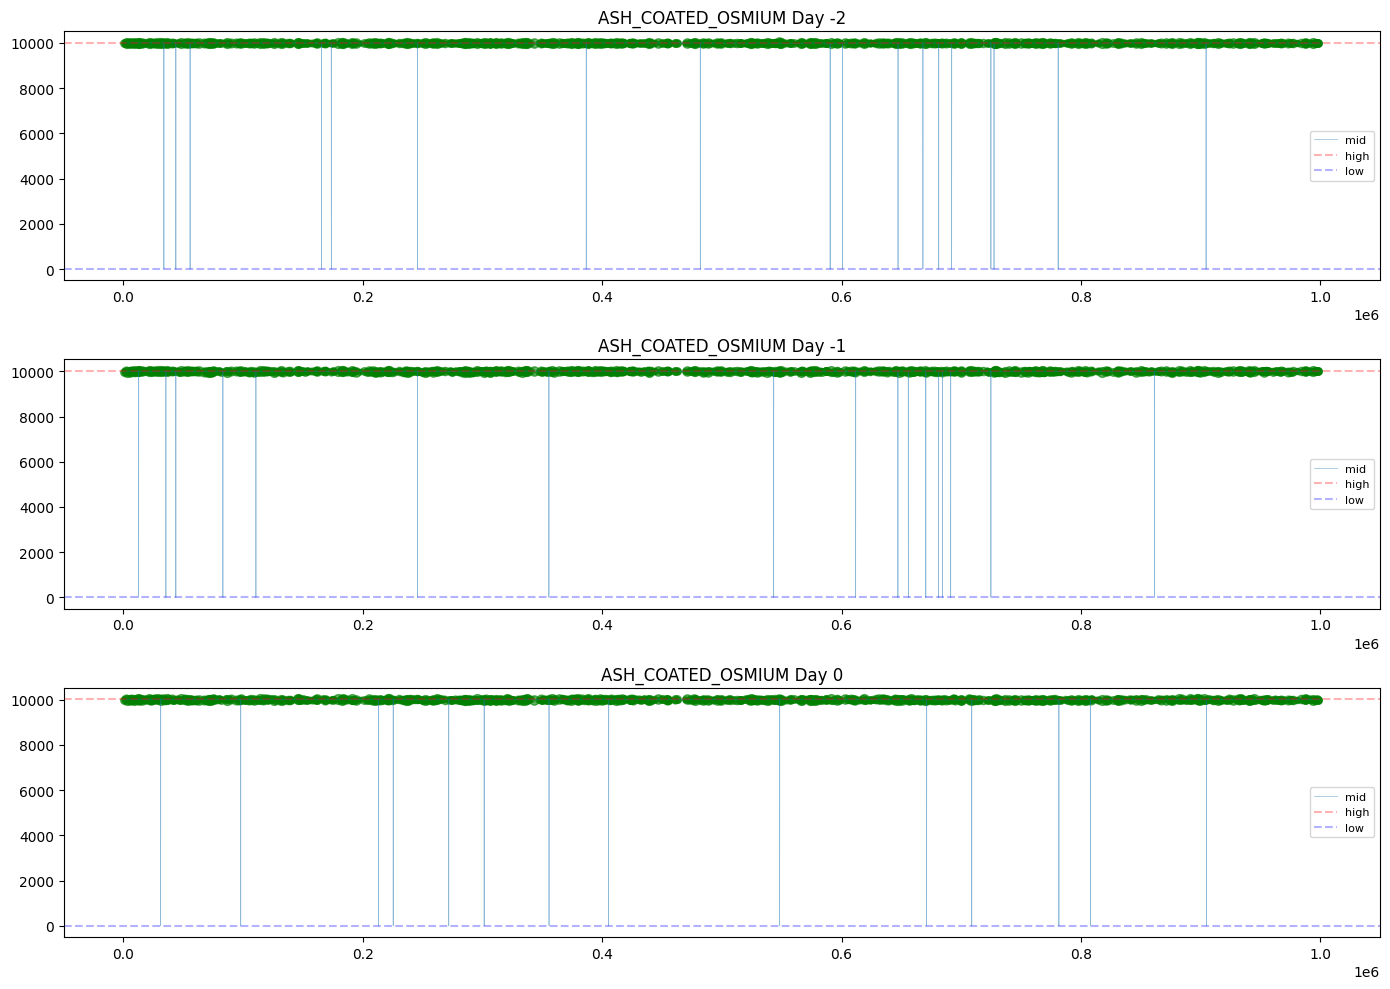


ASH_COATED_OSMIUM — trades near daily high/low:
  Day -2: 0 trades near low, 1265 near high
    Near high qtys: [6, 2, 8, 8, 9, 3, 3, 5, 9, 4, 4, 6, 2, 10, 6, 4, 9, 6, 10, 2, 4, 2, 4, 10, 3, 5, 8, 10, 6, 6, 8, 5, 8, 9, 7, 9, 7, 6, 6, 2, 6, 4, 8, 3, 8, 4, 3, 3, 3, 5, 4, 8, 3, 4, 6, 9, 6, 5, 4, 10, 3, 4, 8, 6, 3, 3, 3, 8, 2, 5, 6, 6, 3, 5, 2, 5, 3, 3, 4, 10, 10, 5, 2, 5, 3, 6, 5, 9, 3, 6, 2, 3, 3, 2, 9, 2, 6, 5, 2, 3, 4, 4, 4, 2, 9, 10, 2, 5, 4, 2, 3, 4, 2, 4, 2, 2, 5, 7, 3, 4, 3, 2, 5, 3, 4, 5, 6, 10, 7, 6, 7, 2, 6, 6, 2, 6, 10, 6, 5, 5, 9, 7, 4, 4, 6, 3, 7, 6, 6, 6, 10, 5, 3, 6, 4, 6, 4, 6, 2, 9, 5, 6, 6, 8, 6, 7, 2, 4, 3, 5, 5, 7, 7, 3, 8, 9, 6, 7, 5, 6, 2, 8, 9, 6, 6, 3, 6, 10, 7, 4, 9, 3, 6, 2, 2, 6, 3, 4, 7, 5, 6, 6, 3, 2, 5, 5, 5, 2, 4, 3, 6, 3, 4, 4, 2, 3, 3, 3, 4, 9, 3, 6, 7, 7, 6, 6, 3, 4, 3, 8, 4, 6, 4, 6, 9, 4, 6, 2, 4, 6, 10, 8, 6, 6, 2, 3, 3, 8, 9, 5, 5, 2, 6, 4, 4, 10, 8, 3, 10, 5, 6, 4, 6, 6, 3, 4, 6, 4, 8, 3, 5, 4, 4, 9, 2, 8, 6, 2, 10, 3, 10, 5, 4, 4, 9, 3, 2, 6, 5, 2,

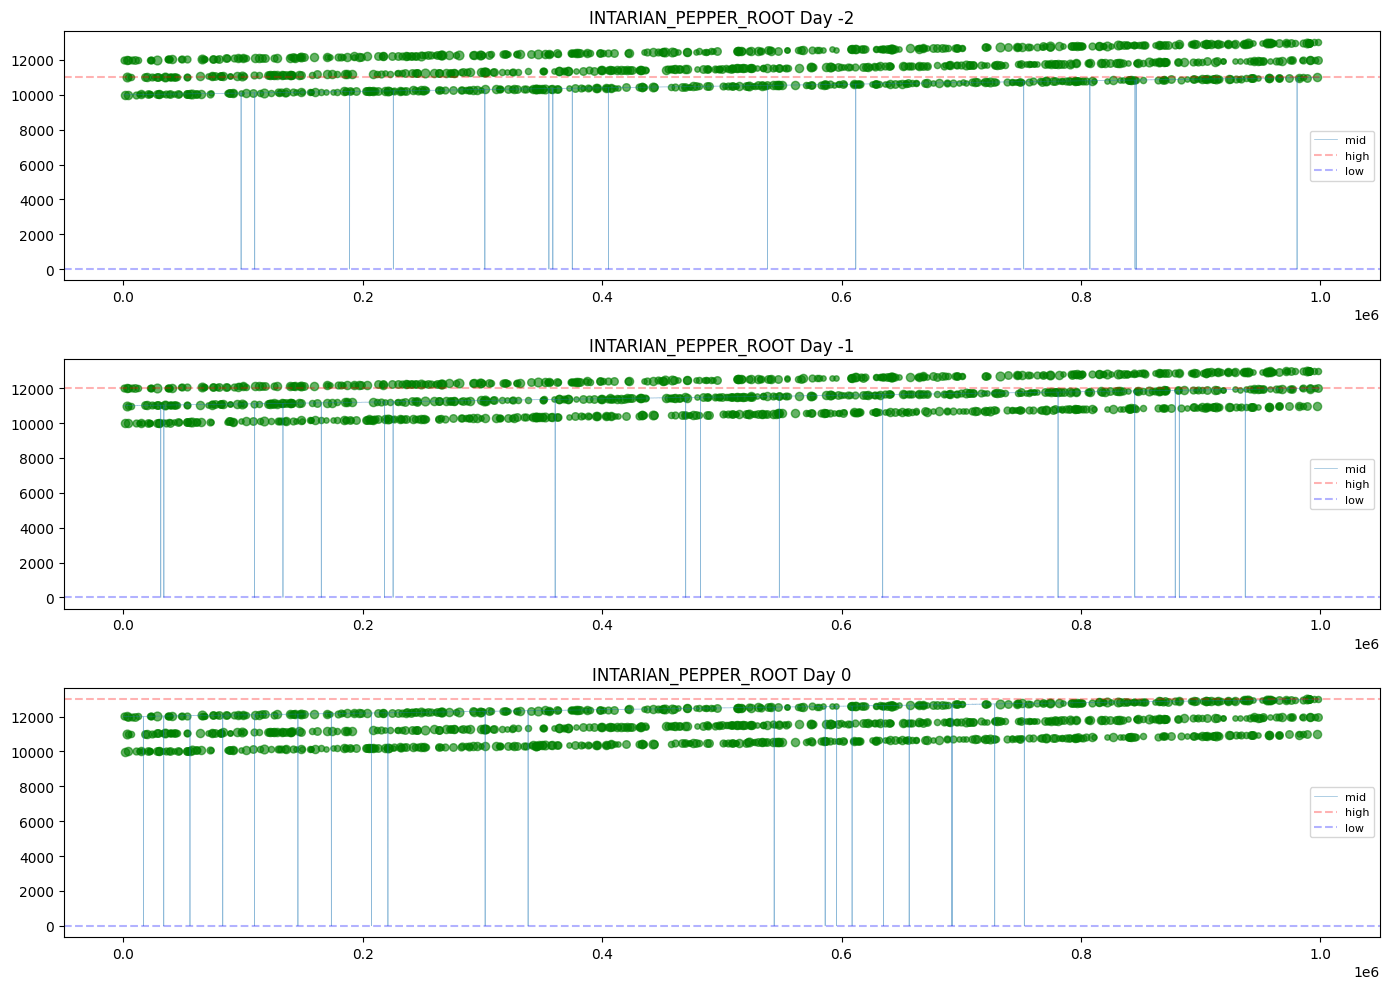


INTARIAN_PEPPER_ROOT — trades near daily high/low:
  Day -2: 0 trades near low, 1011 near high
    Near high qtys: [7, 7, 5, 3, 7, 3, 6, 4, 3, 4, 6, 6, 7, 3, 5, 4, 6, 3, 6, 4, 6, 6, 4, 7, 8, 6, 5, 7, 5, 3, 3, 6, 6, 5, 7, 3, 7, 6, 4, 8, 4, 5, 4, 5, 5, 7, 5, 3, 7, 3, 4, 3, 3, 7, 4, 3, 3, 4, 7, 3, 5, 6, 3, 6, 6, 6, 7, 6, 4, 5, 7, 4, 5, 6, 7, 3, 3, 8, 6, 3, 5, 7, 5, 4, 5, 6, 7, 4, 5, 7, 5, 7, 4, 3, 6, 4, 5, 6, 5, 5, 4, 5, 5, 7, 7, 3, 7, 7, 4, 5, 4, 6, 4, 7, 6, 5, 5, 3, 7, 7, 8, 6, 3, 7, 4, 7, 5, 8, 6, 7, 6, 5, 3, 6, 5, 3, 5, 3, 7, 7, 4, 3, 7, 5, 7, 5, 3, 3, 6, 5, 7, 7, 4, 8, 6, 4, 5, 6, 6, 3, 3, 3, 7, 6, 4, 6, 6, 5, 3, 5, 3, 6, 5, 3, 3, 7, 6, 6, 8, 3, 4, 6, 7, 6, 5, 6, 7, 7, 7, 5, 7, 7, 7, 4, 3, 6, 5, 5, 7, 6, 6, 5, 3, 3, 4, 6, 3, 3, 7, 4, 5, 3, 5, 5, 5, 3, 5, 6, 5, 4, 3, 3, 7, 6, 3, 7, 3, 4, 3, 6, 4, 4, 3, 6, 7, 3, 7, 5, 3, 5, 3, 3, 3, 5, 7, 6, 3, 7, 6, 8, 6, 4, 5, 4, 3, 3, 3, 4, 6, 3, 5, 5, 4, 6, 8, 6, 6, 6, 3, 3, 4, 5, 6, 4, 5, 4, 7, 4, 3, 6, 6, 4, 5, 5, 7, 3, 3, 7, 3, 3, 5, 6, 4, 6, 4

In [28]:
# Anonymous trades — detect by behavior pattern instead
# Look for: fixed quantity, trades near daily extremes

for symbol in ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]:
    sym_trades = trades[trades["symbol"] == symbol].copy()
    sym_prices = prices[prices["product"] == symbol].copy()
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    for i, (day, day_prices) in enumerate(sym_prices.groupby("day")):
        day_trades = sym_trades[sym_trades["timestamp"].between(
            day_prices["timestamp"].min(), day_prices["timestamp"].max()
        )]
        
        mid = day_prices.set_index("timestamp")["mid_price"]
        
        # Plot mid price with trade markers
        axes[i].plot(mid.index, mid.values, linewidth=0.5, alpha=0.5, label="mid")
        
        # Overlay trades, sized by quantity, colored by buyer/seller
        for _, t in day_trades.iterrows():
            if t["timestamp"] in mid.index:
                axes[i].scatter(t["timestamp"], t["price"], 
                               s=t["quantity"] * 5, alpha=0.6, color="green")
        
        # Mark daily high/low
        axes[i].axhline(mid.max(), color="red", linestyle="--", alpha=0.3, label="high")
        axes[i].axhline(mid.min(), color="blue", linestyle="--", alpha=0.3, label="low")
        axes[i].set_title(f"{symbol} Day {day}")
        axes[i].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

    # Check: are there trades clustering near daily extremes?
    print(f"\n{symbol} — trades near daily high/low:")
    for day, day_prices in sym_prices.groupby("day"):
        day_trades = sym_trades[sym_trades["timestamp"].between(
            day_prices["timestamp"].min(), day_prices["timestamp"].max()
        )]
        mid = day_prices["mid_price"]
        high, low = mid.max(), mid.min()
        rng = high - low if high != low else 1
        
        near_high = day_trades[day_trades["price"] >= high - 0.1 * rng]
        near_low = day_trades[day_trades["price"] <= low + 0.1 * rng]
        
        print(f"  Day {day}: {len(near_low)} trades near low, {len(near_high)} near high")
        if len(near_low) > 0:
            print(f"    Near low qtys: {near_low['quantity'].tolist()}")
        if len(near_high) > 0:
            print(f"    Near high qtys: {near_high['quantity'].tolist()}")

In [31]:
# Reload data with day column on trades
trades = pd.concat([
    pd.read_csv(DATA_DIR / f"trades_round_1_day_{d}.csv", sep=";").assign(day=d)
    for d in [-2, -1, 0]
], ignore_index=True)

# Filter to OSMIUM
osmium_p = prices[prices["product"] == "ASH_COATED_OSMIUM"].copy()
osmium_p = osmium_p[osmium_p["bid_price_1"].notna() & osmium_p["ask_price_1"].notna()]
osmium_t = trades[trades["symbol"] == "ASH_COATED_OSMIUM"].copy()

# Join on (day, timestamp) instead of timestamp alone
book_at_t = osmium_p.set_index(["day", "timestamp"])
osmium_t = osmium_t.join(
    book_at_t[["bid_price_1", "ask_price_1", "mid_price"]],
    on=["day", "timestamp"]
).dropna(subset=["bid_price_1"])

# Classify
osmium_t["side"] = osmium_t.apply(
    lambda r: "BUY_CROSS" if r["price"] >= r["ask_price_1"]
              else "SELL_CROSS" if r["price"] <= r["bid_price_1"]
              else "INSIDE", axis=1
)

print("=== Trade classification ===")
print(osmium_t["side"].value_counts())
print()

print("=== Buy crosses: how far above best ask? ===")
buy_crosses = osmium_t[osmium_t["side"] == "BUY_CROSS"].copy()
buy_crosses["above_best_ask"] = (buy_crosses["price"] - buy_crosses["ask_price_1"]).astype(int)
print(buy_crosses["above_best_ask"].value_counts().sort_index())
print()

print("=== Sell crosses: how far below best bid? ===")
sell_crosses = osmium_t[osmium_t["side"] == "SELL_CROSS"].copy()
sell_crosses["below_best_bid"] = (sell_crosses["bid_price_1"] - sell_crosses["price"]).astype(int)
print(sell_crosses["below_best_bid"].value_counts().sort_index())
print()

print("=== Sweeps (>1 trade per timestamp) ===")
sweeps = osmium_t.groupby(["day", "timestamp"]).agg(n_trades=("price", "size"))
print(f"Ticks with >1 trade: {(sweeps['n_trades'] > 1).sum()} / {len(sweeps)}")
print(sweeps["n_trades"].value_counts().sort_index())

=== Trade classification ===
side
BUY_CROSS     628
SELL_CROSS    601
Name: count, dtype: int64

=== Buy crosses: how far above best ask? ===
above_best_ask
0    628
Name: count, dtype: int64

=== Sell crosses: how far below best bid? ===
below_best_bid
0    601
Name: count, dtype: int64

=== Sweeps (>1 trade per timestamp) ===
Ticks with >1 trade: 13 / 1216
n_trades
1    1203
2      13
Name: count, dtype: int64
